# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Diovalda22/flyrank-ml-internship/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*
<br>
I am choosing the Content Opportunity Scoring lane. I chose this because a machine learning model can analyze a massive amount of content, helping the team prioritize and easily identify which pages must be updated first to reduce high business risk

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*
<br>
<br>
**The Decision:** This work replaces random manual checks and guesswork with a data-driven priority queue, organizing content updates from most urgent to least urgent.
<br>
**The Action:** The content team or editors will act on these recommendations by updating, rewriting, or optimizing the high-priority pages first.
<br>
**The Cost:** A wrong recommendation has two main costs. A false positive wastes resources, causing the team to spend their limited time editing pages that are actually doing fine. Conversely, a false negative costs business impact: high-traffic pages are left to decay unseen, eventually losing their search visibility and overall traffic.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*
<br>
<br>
**High Business Risk (Opportunity Cost):**
There are 9,961 high-impression pages that are currently declining. If the team selects the wrong pages to update (for example, spending time on pages with only 5 impressions), they waste valuable work hours while these 9,961 key pages continue to decay and lose visibility.

**The Role of Machine Learning (Decision-Support):**
The ML model is not here to replace writers or editors, but rather to build a data-driven priority queue. This ensures the editorial team knows exactly which of those 9,961 critical pages are the most urgent to address first.

Total Content Items: 30,000
Declining Content Items: 16,262 (54.2%)
High Demand Pages (>=500 impressions): 16,726
High Demand Pages currently Declining: 9,961


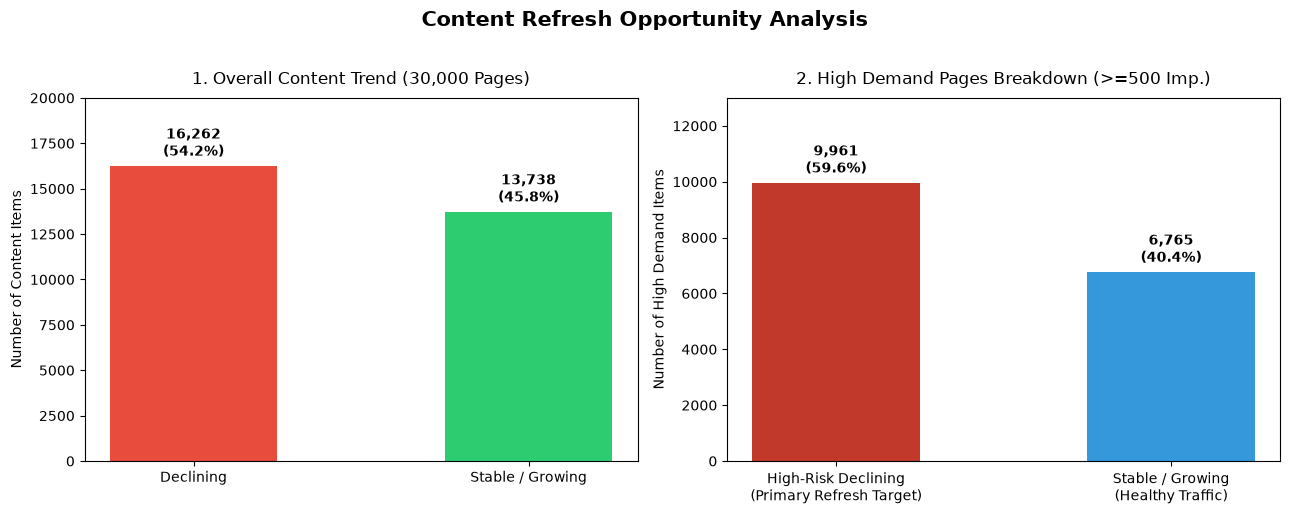

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Dataset
file_path = '../../data/raw/content_refresh_anonymized.csv'
if not os.path.exists(file_path):
    file_path = 'data/raw/content_refresh_anonymized.csv'
df = pd.read_csv(file_path)

# 2. Calculate Key Metrics
total_pages = len(df)
declining_pages = (df['trend_direction'] == 'down').sum()
non_declining_pages = total_pages - declining_pages
pct_declining = (declining_pages / total_pages) * 100

high_imp_df = df[df['impressions_90d'] >= 500]
high_imp_total = len(high_imp_df)
high_imp_declining = (high_imp_df['trend_direction'] == 'down').sum()
high_imp_stable = high_imp_total - high_imp_declining

# Print Text Metrics
print(f"Total Content Items: {total_pages:,}")
print(f"Declining Content Items: {declining_pages:,} ({pct_declining:.1f}%)")
print(f"High Demand Pages (>=500 impressions): {high_imp_total:,}")
print(f"High Demand Pages currently Declining: {high_imp_declining:,}")

# 3. Create Visualizations
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Content Refresh Opportunity Analysis', fontsize=15, fontweight='bold', y=1.02)

# Subplot 1: Overall Content Trend Comparison
categories_1 = ['Declining', 'Stable / Growing']
values_1 = [declining_pages, non_declining_pages]
colors_1 = ['#e74c3c', '#2ecc71']

bars1 = axes[0].bar(categories_1, values_1, color=colors_1, width=0.5)
axes[0].set_title('1. Overall Content Trend (30,000 Pages)', fontsize=12, pad=10)
axes[0].set_ylabel('Number of Content Items', fontsize=10)
axes[0].set_ylim(0, 20000)

# Add data labels on top of bars
for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 300, f'{yval:,}\n({yval/total_pages*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: High Demand Pages Breakdown (>=500 impressions)
categories_2 = ['High-Risk Declining\n(Primary Refresh Target)', 'Stable / Growing\n(Healthy Traffic)']
values_2 = [high_imp_declining, high_imp_stable]
colors_2 = ['#c0392b', '#3498db']

bars2 = axes[1].bar(categories_2, values_2, color=colors_2, width=0.5)
axes[1].set_title('2. High Demand Pages Breakdown (>=500 Imp.)', fontsize=12, pad=10)
axes[1].set_ylabel('Number of High Demand Items', fontsize=10)
axes[1].set_ylim(0, 13000)

# Add data labels on top of bars
for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 200, f'{yval:,}\n({yval/high_imp_total*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*
<br>
<br>
**What I can claim (Observed & Decision-Support):**
This work acts strictly as a decision-support tool based on observed historical data. I can claim that the model successfully identifies patterns in search signals and effectively prioritizes a review queue to highlight pages that most likely need human attention. 

**What I cannot claim (No Causal Proof & Not Predicting Google):**
I cannot claim causal proof—meaning I cannot guarantee that refreshing a highly-scored page will automatically cause a traffic recovery. Additionally, I cannot claim that this model reverse-engineers, proves, or predicts Google's search algorithm factors.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.